# Chapter 6 — Linear Regression

**Goals**

- Fit a univariate linear model on a toy dataset (closed form + GD).
- Move to the multivariate case on California Housing.
- Solve linear regression two ways: **normal equation** and **gradient descent**.
- Compare against `sklearn.linear_model.LinearRegression`.
- Report MSE, RMSE, MAE, and $R^2$ on a held-out test set.

Pair with `docs/03_regression.md`, Part A.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. Univariate warm-up

True data-generating process: $y = 2x + 1 + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, 0.3^2)$. We pretend we don't know that and fit $\hat{y} = wx + b$ both with the normal equation and with gradient descent.

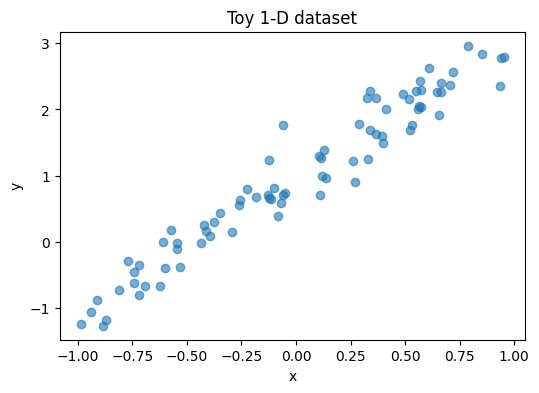

In [2]:
N = 80
x = rng.uniform(-1.0, 1.0, size=N)
y = 2.0 * x + 1.0 + rng.normal(0, 0.3, size=N)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, alpha=0.6)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Toy 1-D dataset')
plt.show()

### 2.1 Normal equation (closed form)

In [3]:
X1 = np.column_stack([x, np.ones_like(x)])     # design matrix [x, 1]
w_closed = np.linalg.inv(X1.T @ X1) @ (X1.T @ y)
w_hat, b_hat = w_closed
print(f'closed form: w = {w_hat:.4f}, b = {b_hat:.4f}  (true 2.0, 1.0)')

closed form: w = 2.0698, b = 0.9621  (true 2.0, 1.0)


### 2.2 Gradient descent

Same answer (up to optimization tolerance) via the iterative loop from Chapter 4.

gradient descent: w = 2.0698, b = 0.9621


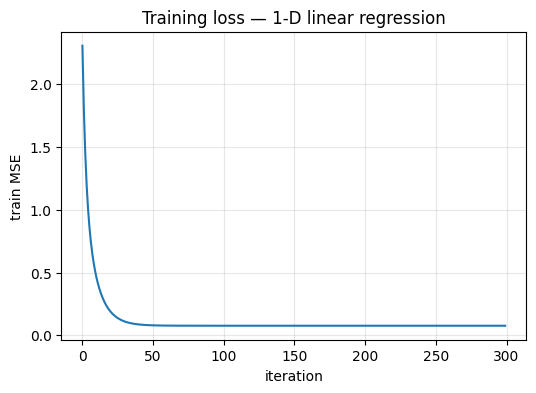

In [4]:
def fit_gd(x, y, lr=0.1, n_iters=300):
    w, b = 0.0, 0.0
    history = []
    for _ in range(n_iters):
        y_hat = w * x + b
        err = y_hat - y
        gw = 2.0 * np.mean(err * x)
        gb = 2.0 * np.mean(err)
        w -= lr * gw
        b -= lr * gb
        history.append(float(np.mean(err ** 2)))
    return w, b, np.array(history)

w_gd, b_gd, losses = fit_gd(x, y, lr=0.1, n_iters=300)
print(f'gradient descent: w = {w_gd:.4f}, b = {b_gd:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses)
ax.set_xlabel('iteration'); ax.set_ylabel('train MSE')
ax.set_title('Training loss — 1-D linear regression')
ax.grid(True, alpha=0.3)
plt.show()

### 2.3 Compare

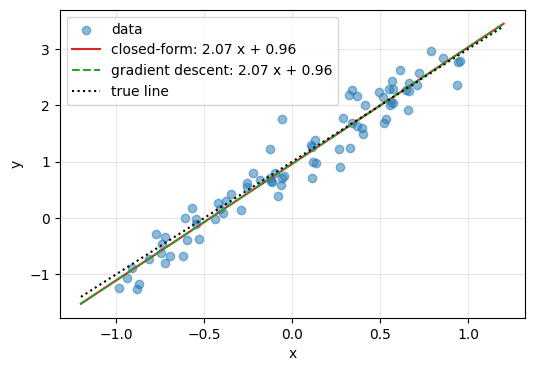

In [5]:
xs = np.linspace(-1.2, 1.2, 100)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, alpha=0.5, label='data')
ax.plot(xs, w_hat * xs + b_hat, color='tab:red',   label=f'closed-form: {w_hat:.2f} x + {b_hat:.2f}')
ax.plot(xs, w_gd   * xs + b_gd,   color='tab:green', ls='--', label=f'gradient descent: {w_gd:.2f} x + {b_gd:.2f}')
ax.plot(xs, 2.0 * xs + 1.0, color='black', ls=':', label='true line')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 3. Multivariate linear regression — California Housing

Same idea, but now `X` has 8 features. Closed form, GD, and sklearn all on equal footing.

### 3.1 Load and split

In [6]:
data = fetch_california_housing(as_frame=True)
df = data.frame
X_raw = df.drop(columns=['MedHouseVal']).values
y_all = df['MedHouseVal'].values
feature_names = data.feature_names

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_all, test_size=0.2, random_state=SEED
)
scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
print('train:', X_train.shape, 'test:', X_test.shape)

train: (16512, 8) test: (4128, 8)


### 3.2 Normal equation

Augment `X` with a column of 1s so the bias is the last weight. Solve $\mathbf{w}^\star = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$.

In [7]:
def add_bias(X):
    return np.hstack([X, np.ones((X.shape[0], 1))])

Xb_train = add_bias(X_train)
Xb_test  = add_bias(X_test)

w_normal = np.linalg.solve(Xb_train.T @ Xb_train, Xb_train.T @ y_train)
y_pred_normal = Xb_test @ w_normal
print(f'normal-eq test RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_normal)):.4f}')

normal-eq test RMSE = 0.7456


We used `np.linalg.solve` instead of explicitly inverting — same math, better numerics.

### 3.3 Gradient descent

GD test RMSE       = 0.7458


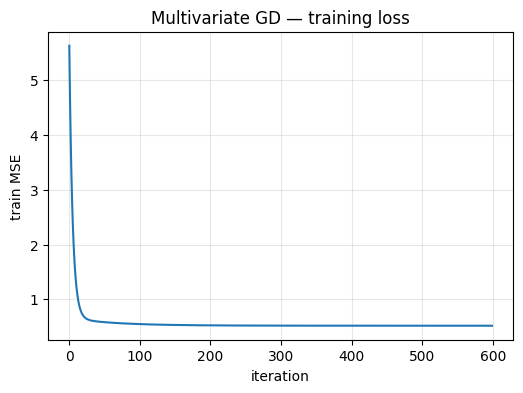

In [8]:
def fit_linear_gd(X, y, lr=0.05, n_iters=600):
    N, d = X.shape
    Xb = add_bias(X)
    w = np.zeros(d + 1)
    losses = []
    for _ in range(n_iters):
        err = Xb @ w - y
        grad = (2.0 / N) * (Xb.T @ err)
        w -= lr * grad
        losses.append(float(np.mean(err ** 2)))
    return w, np.array(losses)

w_gd, losses = fit_linear_gd(X_train, y_train, lr=0.05, n_iters=600)
y_pred_gd = add_bias(X_test) @ w_gd
print(f'GD test RMSE       = {np.sqrt(mean_squared_error(y_test, y_pred_gd)):.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses)
ax.set_xlabel('iteration'); ax.set_ylabel('train MSE')
ax.set_title('Multivariate GD — training loss')
ax.grid(True, alpha=0.3)
plt.show()

### 3.4 scikit-learn

In [9]:
lr_sk = LinearRegression().fit(X_train, y_train)
y_pred_sk = lr_sk.predict(X_test)
print(f'sklearn test RMSE   = {np.sqrt(mean_squared_error(y_test, y_pred_sk)):.4f}')

sklearn test RMSE   = 0.7456


### 3.5 Compare all three methods (and the weights they produced)

In [10]:
weights = pd.DataFrame({
    'feature':     list(feature_names) + ['bias'],
    'normal_eq':   w_normal,
    'gradient_descent': w_gd,
    'sklearn':     list(lr_sk.coef_) + [lr_sk.intercept_],
})
weights.set_index('feature').round(4)

,normal_eq,gradient_descent,sklearn
feature,,,
MedInc,0.8544,0.8601,0.8544
HouseAge,0.1225,0.1247,0.1225
AveRooms,-0.2944,-0.3030,-0.2944
AveBedrms,0.3393,0.3454,0.3393
Population,-0.0023,-0.0016,-0.0023
AveOccup,-0.0408,-0.0412,-0.0408
Latitude,-0.8969,-0.8760,-0.8969
Longitude,-0.8698,-0.8495,-0.8698
bias,2.0719,2.0719,2.0719


All three columns agree (to a few decimals). GD's intercept lags the closed-form values slightly because GD hasn't fully converged after 600 iterations — try `n_iters=2000` and the gap closes.

## 4. Full metric report (test set, sklearn fit)

In [11]:
y_pred = lr_sk.predict(X_test)
metrics = {
    'MSE':  mean_squared_error(y_test, y_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred))),
    'MAE':  mean_absolute_error(y_test, y_pred),
    'R2':   r2_score(y_test, y_pred),
}
pd.Series(metrics).round(4)

MSE     0.5559
RMSE    0.7456
MAE     0.5332
R2      0.5758
dtype: float64

$R^2 \approx 0.58$ — the linear model explains about 58% of the variance in California house prices. That's the ceiling of "good linear features"; you need non-linear models to beat it.

### Residuals — diagnostic

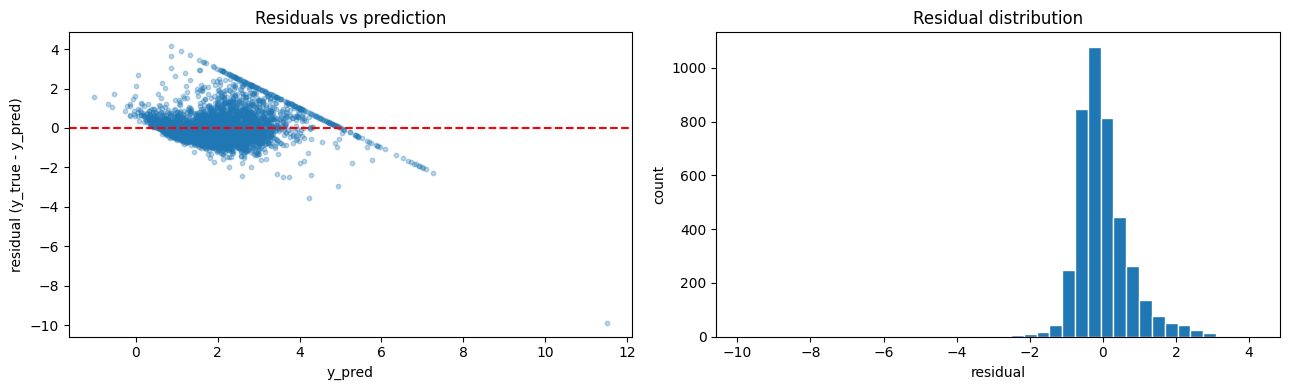

In [12]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('y_pred'); axes[0].set_ylabel('residual (y_true - y_pred)')
axes[0].set_title('Residuals vs prediction')
axes[1].hist(residuals, bins=40, edgecolor='white')
axes[1].set_xlabel('residual'); axes[1].set_ylabel('count')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.show()

The residuals look roughly Gaussian but with heavy tails and a visible upper truncation (the dataset caps house value at \$500k). That truncation is a sign that linear regression is the wrong tool at the top of the price range — a topic for Chapter 7's overfitting / model-mismatch discussion.

## 5. Summary

- Linear regression: $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b\mathbf{1}$, MSE loss, three solvers (normal equation, GD, sklearn).
- All three give the same weights up to numerical noise.
- Always report RMSE *and* MAE *and* $R^2$ — they give different views of the error.
- Residual plots are free diagnostics; use them.

**Next:** `notebooks/chapter_05_overfitting_regularization.ipynb` — what happens when the model is *too* flexible.

## Quick Check

1. Write the linear-regression hypothesis and the MSE loss in one line each.
2. Why does the normal equation fail when $X^\top X$ is singular, and what is a fix?
3. Increasing the learning rate too far causes which two symptoms in the loss curve?
4. Why does feature scaling speed up gradient descent for linear regression?
5. State one situation where $R^2$ is misleading and you should look at MAE/MSE instead.


## Further Reading

- Vũ Hữu Tiệp, *Machine Learning cơ bản* — Chương 7 (Linear Regression).
- Andrew Ng, *CS229 Lecture Notes*, Set 1.
- scikit-learn user guide: *Linear Models*.
